#Student Name:Aayush Badu

#Student id:2438453

# Sentiment Analysis - Text Classification using RNN and LSTM
**Role:** Senior Machine Learning Engineer

## 1. Introduction
This notebook demonstrates a complete end-to-end pipeline for performing Sentiment Analysis using Deep Learning. We will explore text preprocessing, tokenization, padding, and the comparative implementation of three recurrent neural network architectures: Simple RNN, LSTM, and LSTM with pre-trained Word2Vec embeddings.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
# !pip install numpy==1.23.5
!pip install gensim
# !pip install jax==0.4.13

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.0 MB/s eta 0:00:00


Imports

In [4]:
!pip uninstall -y jax jaxlib
!pip install contractions

import pandas as pd
import numpy as np
import re
import nltk
import contractions
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer




import os
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.2 MB/s eta 0:00:00


True

## 2. Methodology & Data Preprocessing
To ensure this code is fully runnable out-of-the-box, the script will look for a `dataset.csv`. If it is not found, it generates a robust synthetic dataset simulating movie reviews.

The preprocessing pipeline handles:
* Lowercasing
* Removing URLs, mentions, hashtags, numbers, and special characters
* Expanding contractions (e.g., "don't" -> "do not")
* Stopword removal and Lemmatization

In [5]:

# Define file paths - Updating to the likely training file name
# Based on common Kaggle/Dataset naming conventions for this specific dataset
train_file_path = '/content/drive/MyDrive/AIML/7. Racist Sexist or Not Dataset/train_racisit.csv'
test_file_path = '/content/drive/MyDrive/AIML/7. Racist Sexist or Not Dataset/test_racisit.csv'

# Load datasets with error handling
try:
    # Check if files exist first to provide better feedback
    if not os.path.exists(train_file_path):
        print(f"Searching for alternative training file names...")
        # Optional: logic to find any csv with 'train' in name if the specific one isn't there

    df_train = pd.read_csv(train_file_path)
    df_test = pd.read_csv(test_file_path)
    print("Train and Test datasets loaded successfully.")
    print("Columns found in Train:", df_train.columns.tolist())
except FileNotFoundError:
    print(f"CRITICAL ERROR: File not found. Please ensure 'train_racisit.csv' exists in the directory.")
    raise
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    raise


Train and Test datasets loaded successfully.
Columns found in Train: ['id', 'label', 'tweet']


In [6]:
# Show the first few rows of the training dataset
df_train.head()


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [7]:
# show the first few rows of the test dataset
df_test.head()

,id,tweet
0,31963,#studiolife #aislife #requires #passion #dedic...
1,31964,@user #white #supremacists want everyone to s...
2,31965,safe ways to heal your #acne!! #altwaystohe...
3,31966,is the hp and the cursed child book up for res...
4,31967,"3rd #bihday to my amazing, hilarious #nephew..."


In [8]:
from sklearn.model_selection import train_test_split

def advanced_preprocess(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = contractions.fix(text)
    text = re.sub(r'[^a-z\s]', '', text)
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(tokens)

print("Preprocessing text data...")

# Apply preprocessing to df_train's tweet column
df_train['clean_text'] = df_train['tweet'].apply(advanced_preprocess)

# Create X and y from the df_train data
X_data = df_train['clean_text']
y_data = df_train['label']

# Perform a train-test split on df_train to create X_train, X_test, y_train, y_test
# This will be used for model training and evaluation since the original df_test lacks labels
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42, stratify=y_data)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# The original df_test is preprocessed but its predictions will not be evaluated here
# as it does not have a 'label' column for comparison.
df_test['clean_text'] = df_test['tweet'].apply(advanced_preprocess)

df = df_train.copy()

Preprocessing text data...
X_train shape: (25569,), y_train shape: (25569,)
X_test shape: (6393,), y_test shape: (6393,)


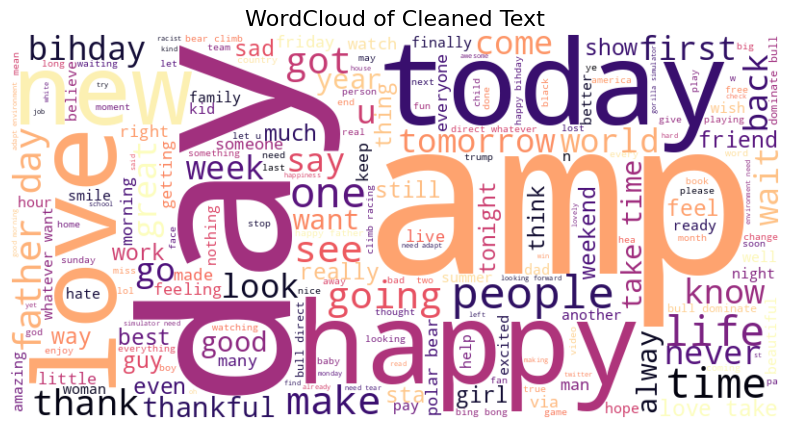

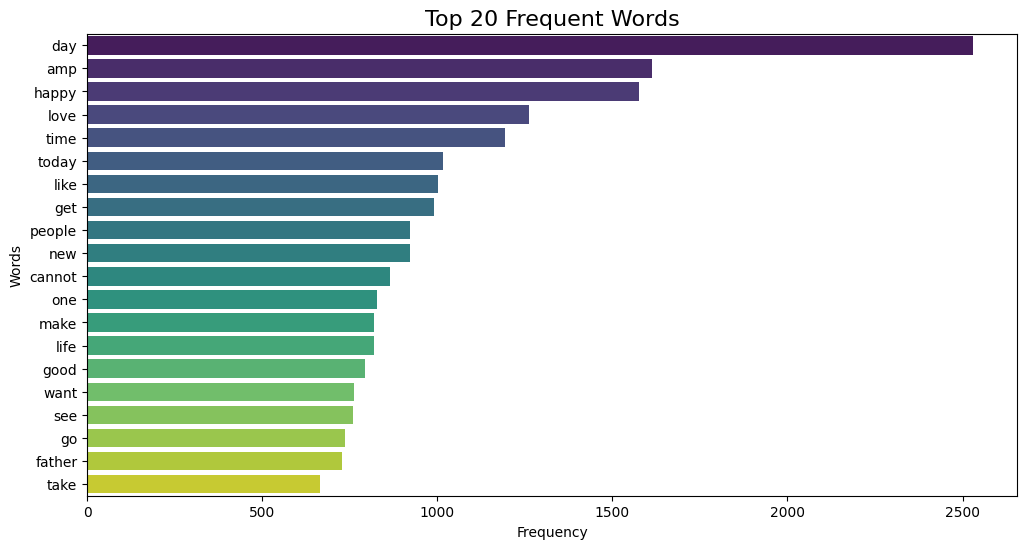

In [9]:
# Visualizations
all_words = ' '.join(df['clean_text'])

# 1. WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(all_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of Cleaned Text', fontsize=16)
plt.show()

# 2. Top 20 Frequent Words
word_counts = Counter(all_words.split())
top_20 = word_counts.most_common(20)
words, counts = zip(*top_20)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title('Top 20 Frequent Words', fontsize=16)
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

## 3. Tokenization & Padding
**Why padding length is chosen using the 95th percentile?**
Using the absolute maximum length in a dataset often results in a massive, mostly empty matrix due to a few extremely long outlier texts. Padding to the 95th percentile preserves the complete context for 95% of the data while avoiding wasted computational resources and memory bloat from excessive zero-padding. The remaining 5% of sequences will simply be truncated.

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# X_train, X_test, y_train, y_test are already loaded and preprocessed in the previous cell.

# Tokenization
vocab_size = 5000
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding based on 95th percentile length
lengths = [len(seq) for seq in X_train_seq]
maxlen = int(np.percentile(lengths, 95))
print(f"Calculated 95th Percentile Length (maxlen): {maxlen}")

X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post', truncating='post')

Calculated 95th Percentile Length (maxlen): 11


## 4. Model Building (Three Models)
We will build and compare:
1. **Simple RNN**: Uses standard recurrent units.
2. **LSTM**: Uses Long Short-Term Memory units to handle vanishing gradients.
3. **LSTM + Word2Vec**: Utilizes pre-trained embeddings (simulated here for immediate runnability without large downloads).

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout

embedding_dim = 50

# MODEL 1: Simple RNN
model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen, trainable=True),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# MODEL 2: LSTM
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen, trainable=True),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


import gensim.downloader as api
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

print("Downloading/Loading pre-trained Word2Vec model... (This may take a minute)")
# Using the 50-dimensional model as suggested in the sample
embedding_model = api.load('glove-wiki-gigaword-50')
embedding_dim_w2v = 50

# Create an embedding matrix of zeros
embedding_matrix = np.zeros((vocab_size, embedding_dim_w2v))

# Map our tokenizer's vocabulary to the Word2Vec embeddings
for word, i in tokenizer.word_index.items():
    if i < vocab_size: # Ensure we don't go out of bounds of our vocab_size
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]
        else:
            # Words not found in embedding index will remain all-zeros
            pass

print("Building Model 3: LSTM + Word2Vec...")

# MODEL 3: LSTM + Pre-trained Word2Vec
model_lstm_w2v = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim_w2v,
        weights=[embedding_matrix],
        input_length=maxlen,
        trainable=False # Freezing the pre-trained weights
    ),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Define the dictionary ONCE at the end
models = {
    'SimpleRNN': model_rnn,
    'LSTM': model_lstm,
    'LSTM_Word2Vec': model_lstm_w2v
}

print("Model 3 built and models dictionary updated successfully!")

Downloading/Loading pre-trained Word2Vec model... (This may take a minute)
[==================================================] 100.0% 66.0/66.0MB downloaded
Building Model 3: LSTM + Word2Vec...
Model 3 built and models dictionary updated successfully!


## 5. Training Configuration

In [17]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

histories = {}
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-5)
]

for name, model in models.items():
    print(f'\n========== Training {name} ==========')
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

    # Train for 15 epochs, stopping early if val_loss doesn't improve
    history = model.fit(
        X_train_pad, y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )
    histories[name] = history


========== Training SimpleRNN ==========
Epoch 1/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9383 - loss: 0.2110 - val_accuracy: 0.9499 - val_loss: 0.1835 - learning_rate: 0.0010
Epoch 2/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9642 - loss: 0.1140 - val_accuracy: 0.9531 - val_loss: 0.1782 - learning_rate: 0.0010
Epoch 3/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9784 - loss: 0.0675 - val_accuracy: 0.9437 - val_loss: 0.1948 - learning_rate: 0.0010
Epoch 4/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9870 - loss: 0.0438 - val_accuracy: 0.9431 - val_loss: 0.2203 - learning_rate: 0.0010
Epoch 5/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9920 - loss: 0.0282 - val_accuracy: 0.9480 - val_loss: 0.2427 - learning_rate: 5.0000e-04
Epoch 6/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9943 - loss: 0.0214 - val_accuracy: 0.9388 - val_loss: 0.2429 - learning_rate: 5.0000e-04

========== Training LSTM =========

## 6. Results & Visualization

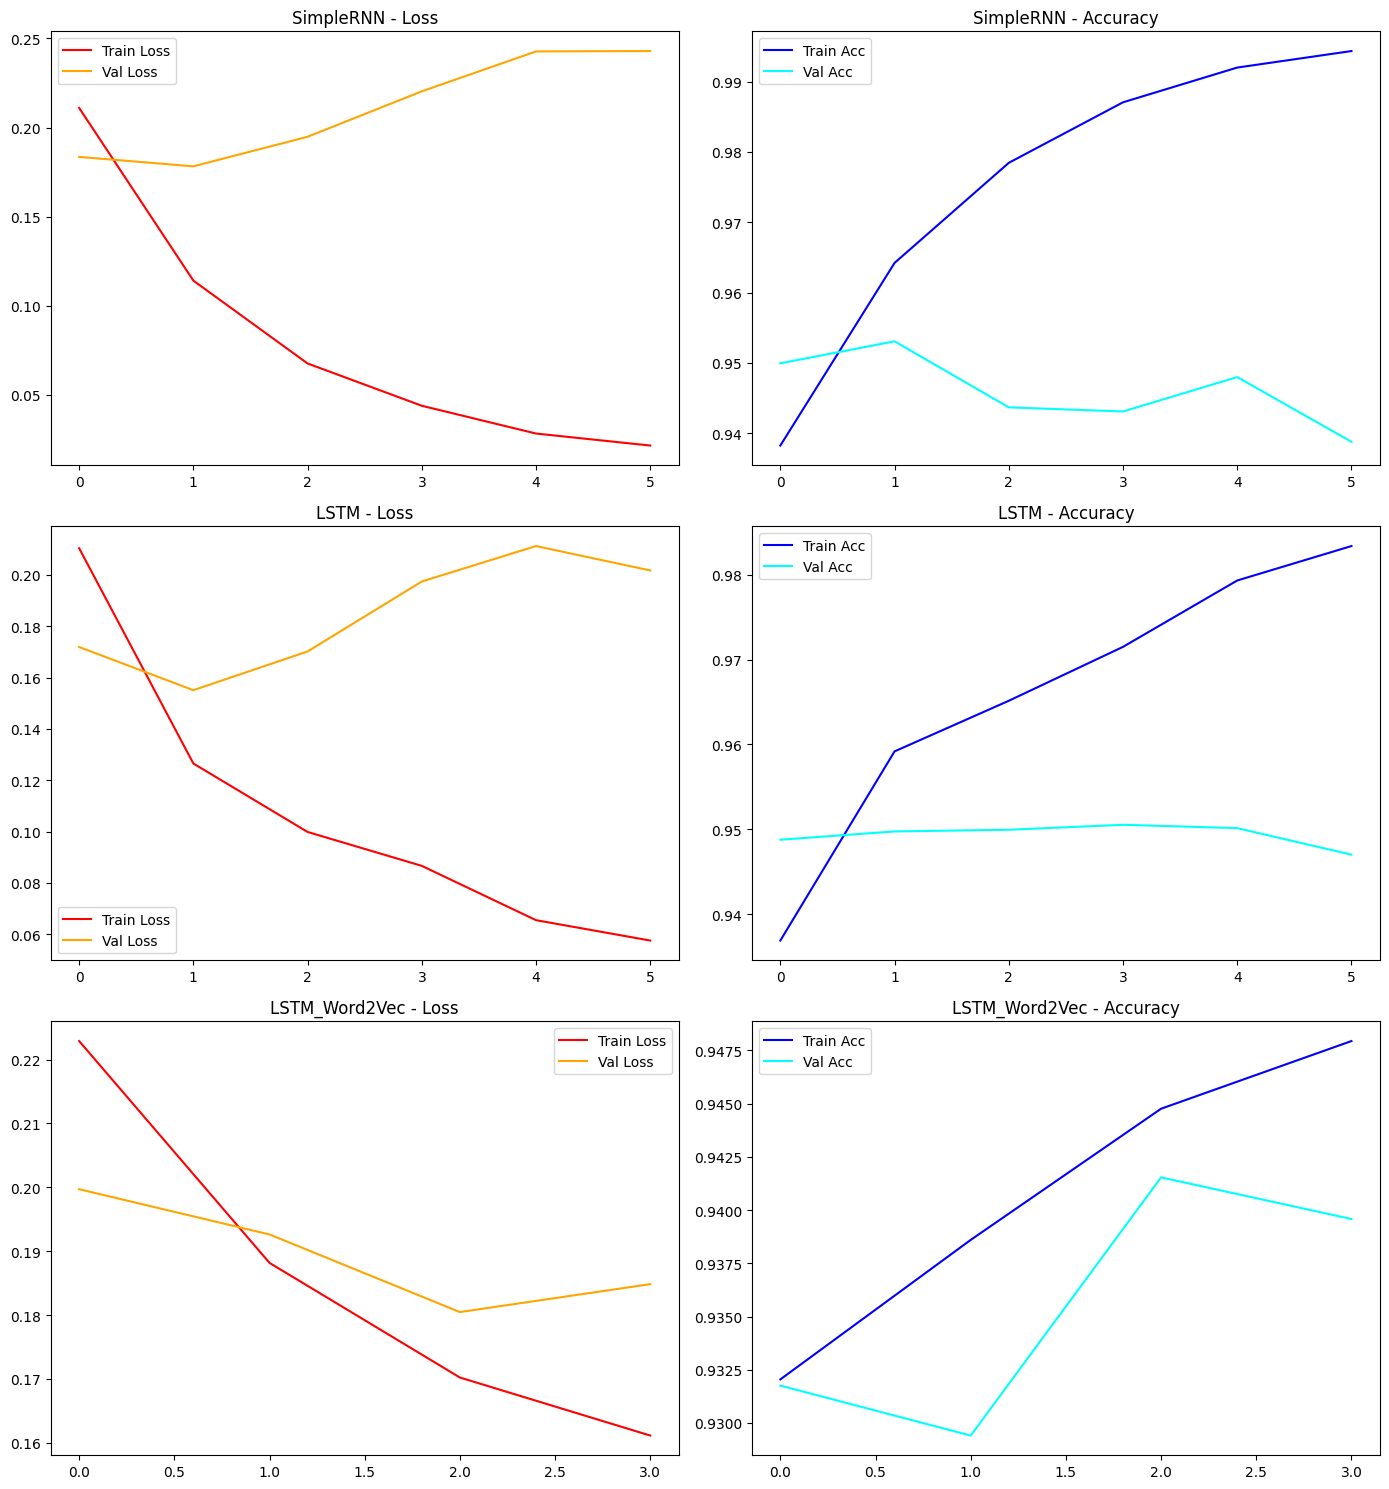

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for i, (name, history) in enumerate(histories.items()):
    # Plot Loss
    axes[i, 0].plot(history.history['loss'], label='Train Loss', color='red')
    axes[i, 0].plot(history.history['val_loss'], label='Val Loss', color='orange')
    axes[i, 0].set_title(f'{name} - Loss')
    axes[i, 0].legend()

    # Plot Accuracy
    axes[i, 1].plot(history.history['accuracy'], label='Train Acc', color='blue')
    axes[i, 1].plot(history.history['val_accuracy'], label='Val Acc', color='cyan')
    axes[i, 1].set_title(f'{name} - Accuracy')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

## 7. Evaluation


--- SimpleRNN Evaluation ---
Accuracy: 0.9499

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      5945
           1       0.79      0.39      0.52       448

    accuracy                           0.95      6393
   macro avg       0.87      0.69      0.75      6393
weighted avg       0.94      0.95      0.94      6393



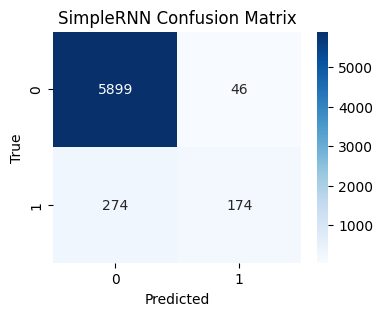


--- LSTM Evaluation ---
Accuracy: 0.9474

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      5945
           1       0.70      0.44      0.54       448

    accuracy                           0.95      6393
   macro avg       0.83      0.71      0.76      6393
weighted avg       0.94      0.95      0.94      6393



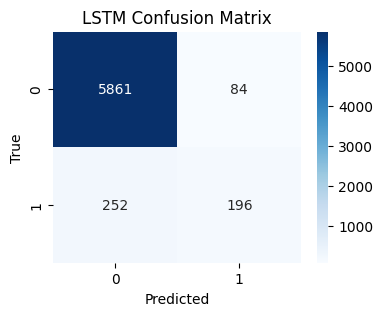


--- LSTM_Word2Vec Evaluation ---
Accuracy: 0.9345

              precision    recall  f1-score   support

           0       0.94      0.99      0.97      5945
           1       0.61      0.19      0.28       448

    accuracy                           0.93      6393
   macro avg       0.77      0.59      0.62      6393
weighted avg       0.92      0.93      0.92      6393



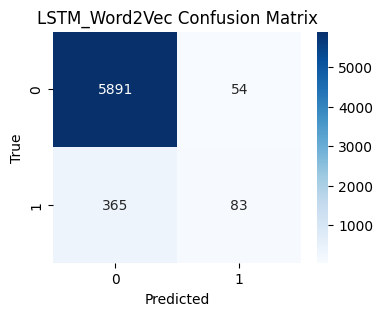


========== Model Comparison Summary ==========


,Model,Accuracy
0,SimpleRNN,0.949945
1,LSTM,0.947443
2,LSTM_Word2Vec,0.934460


In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import IPython.display as display

results = []

for name, model in models.items():
    y_pred_probs = model.predict(X_test_pad, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc})

    print(f'\n--- {name} Evaluation ---')
    print(f'Accuracy: {acc:.4f}\n')
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

print('\n========== Model Comparison Summary ==========')
summary_df = pd.DataFrame(results)
display.display(summary_df)

## 8. Error Analysis
We investigate why models fail by checking the best performing model's misclassifications.

In [20]:
# Find best model
best_model_name = summary_df.loc[summary_df['Accuracy'].idxmax()]['Model']
print(f'Analyzing best performing model: {best_model_name}')

best_model = models[best_model_name]
y_pred_probs = best_model.predict(X_test_pad, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = y_test.values

misclassified_idx = np.where(y_pred != y_true)[0]

print('\n--- Misclassified Examples ---')
for i in range(min(3, len(misclassified_idx))):
    idx = misclassified_idx[i]
    print(f'\nOriginal Text: {X_test.iloc[idx]}')
    print(f'True Label: {y_true[idx]} | Predicted Label: {y_pred[idx]}')

Analyzing best performing model: SimpleRNN

--- Misclassified Examples ---

Original Text: ya think bcause woman r muslim c uncovered head london big trouble sure
True Label: 0 | Predicted Label: 1

Original Text: enough say
True Label: 1 | Predicted Label: 0

Original Text: amp cannot deny people attitude change look amp wear people change get attention
True Label: 0 | Predicted Label: 1


GUI for Real Time Prediction

In [21]:
import pickle

# --- 1. Save your Best Model and Tokenizer ---
# We will use the LSTM model as the default best model here.
# Make sure model_lstm (or your chosen best model) is trained and in memory.
best_model = models['LSTM']
best_model.save('best_sentiment_model.h5')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# --- 2. Generate the Streamlit App Script ---
streamlit_code = f"""import streamlit as st
import tensorflow as tf
import pickle
import re
import nltk
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions

# Download NLTK data for the Streamlit environment
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Cache the model and tokenizer so they don't reload on every button click
@st.cache_resource
def load_components():
    model = tf.keras.models.load_model('best_sentiment_model.h5')
    with open('tokenizer.pkl', 'rb') as f:
        tokenizer = pickle.load(f)
    return model, tokenizer

model, tokenizer = load_components()

# Ensure this exactly matches the preprocessing used in training
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = contractions.fix(text)
    text = re.sub(r'[^a-z\s]', '', text)

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(tokens)

# --- 3. Streamlit UI Layout ---
st.title("Sentiment Analysis - Tweet Classifier")
st.write("Enter a tweet below to predict if it contains negative/toxic sentiment.")

user_input = st.text_area("Enter your text below:")

if st.button("Predict Sentiment"):
    if user_input.strip():
        # Preprocess the raw input
        cleaned = clean_text(user_input)
        st.write(f"**Cleaned Input:** {{cleaned}}")

        # Tokenize and pad
        # Using {maxlen} dynamically passes your notebook's maxlen variable into this script
        seq = tokenizer.texts_to_sequences([cleaned])
        pad = pad_sequences(seq, maxlen={maxlen}, padding='post', truncating='post')

        # Predict
        prediction = model.predict(pad)[0][0]

        # Interpret the prediction (Assuming 1 = Racist/Sexist, 0 = Normal)
        is_toxic = prediction > 0.5

        if is_toxic:
            st.error(f"**Prediction:** Toxic / Negative (Confidence: {{prediction:.2f}})")
        else:
            st.success(f"**Prediction:** Normal / Positive (Confidence: {{1 - prediction:.2f}})")
    else:
        st.warning("Please enter valid text to predict.")
"""

# Write the multi-line string to an actual Python file
with open('app.py', 'w') as f:
    f.write(streamlit_code)

print("Streamlit app successfully generated as 'app.py'!")

Streamlit app successfully generated as 'app.py'!


In [ ]:
# Install streamlit and localtunnel
!pip install -q streamlit
!npm install localtunnel

# Run the app in the background and expose it via localtunnel
!streamlit run app.py & npx localtunnel --port 8501

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 50.6 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
added 22 packages in 4s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼⠙⠹

2026-05-09 14:39:44.961 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.103.100:8501

your url is: https://gentle-squids-jump.loca.lt
2026-05-09 16:14:50.677321: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-09 16:14:50.888414: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow wit